In [1]:
# Run this cell to set up the notebook, but please don't change it.
import numpy as np
import math
import datascience
from datascience import *

# These lines set up the plotting functionality and formatting.
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import warnings
warnings.simplefilter("ignore")

In [2]:
movies = Table.read_table('movies.csv')
movies

Title                      | Year | Rating | Genre    | # Words | she        | decid       | talk        | wit         | razor | slam | credit      | rai        | hugh | breez | conscienc   | audienc | cathi | log  | met         | chosen | grip        | booz        | bianca     | doubl | agent       | exit        | carpent | underground | clemenza | gain        | neg         | majesti | studio | chri        | spin        | greater     | eaten | vibrat | stupid      | cigarett    | jesu        | mani        | violin | financi     | bai         | cop         | neighbor    | cd   | england | made        | conni | instinct | took        | jacquelin | mace        | disappear  | waltz | behind      | bourbon | favorit     | benni       | manhattan | nixon | lunch       | principl    | tradit      | counterfeit | sophi | third       | exist       | wouldv      | hero        | theyr       | anytim      | christin | vallei | chess | paid        | burglar | nostril | rubber | human       | british     | plissken | eddi       | gee         | offend      | rebecca | anger       | plant     | famou      | repres      | latest | rent | dip         | bell | andi | so         | london | cooler      | keaton | portland | headlin     | whatta | fatal | sew  | cheer       | davi        | feed        | hudson | ambros | digest | redi | fri         | staff | casino      | occasion | shadow      | work        | restrain | face        | exercis | sidnei | pile | whyd        | teenag      | her         | retir       | hazard | roth | hurrican | impuls | ranger      | pour        | lester | slash | deer | could       | vital | qualiti | coma | incred      | hank        | famili      | duchess | global | virgin      | scientif | between     | holidai     | qualifi | moor | happili | arizona | non         | bruce       | ankl        | constant    | buzz | harder      | ing  | christian   | palmer | tent        | sunset      | damour | cohaagen | advertis | sensat | local       | there      | terri       | sedat | rotten | struck      | deck | past        | bro  | ann         | dump        | kane | slot        | immun | block       | lil  | technic     | tactic | pencil | outsid      | laboratori | easi        | nephew | coffin      | pretti      | coward | verbal      | permiss     | bartend     | wont        | watch       | lindenmey | cosmo      | capabl      | flirt | huge        | berkelei | max  | walter | lime | rico | marvin | aboard      | bacon | account | kirk | quaid | stunt | closet      | due         | nuclear | blind       | pussi       | howdi | snuff       | eas  | now        | leak        | underwear   | westlei | mayb        | theo | limo        | cousin      | illeg       | silli       | against     | done        | district | invad       | ryan | wait        | grudg | charact | hick | jami | lifetim | lecktor | and        | republican | life        | hidden      | wire        | paranoia | network     | messi | uthatu | effort      | carri       | windham | fun         | psychologist | sean | scent | answer      | mom         | wake        | sign        | ho   | relat       | jame | fat         | myself      | disrupt     | scan | vagu        | basket | christma | estim | em          | union | involv      | norman | suspici     | becom       | shoe        | librari     | administr | ford | complic | stuck       | justic      | attack      | releas | econom | hesit       | autopsi | jurisdict | four        | factor | inquiri | lion | meanwhil | prison      | blair | seri       | groceri | surgeri     | season | christi    | clean       | ow          | wrestl | en   | moral       | hungri      | cole | surfer | sixteen     | angl        | shame       | barrel | major       | ago         | lott | airplan | worth       | train       | easili | feller | valentin | harvei | wherev      | francisco   | true        | dramat | boston      | besid       | inspector | orlean | opportun    | nearli | lindsei | photograph | frame | at         | psy

In [3]:
title_index = movies.index_by('Title')
def row_for_title(title):
    """Return the row for a title, similar to the following expression (but faster)
    
    movies.where('Title', title).row(0)
    """
    return title_index.get(title)[0]

row_for_title('toy story')

Row(Title='toy story', Year='1995', Rating=8.1999999999999993, Genre='comedy', # Words=3016, she=0.0017427675148135001, decid=0.00034855350296270001, talk=0.0017427675148135001, wit=0.0, razor=0.0, slam=0.0, credit=0.0, rai=0.0, hugh=0.0, breez=0.0, conscienc=0.0, audienc=0.0, cathi=0.0, log=0.0, met=0.0, chosen=0.0, grip=0.0, booz=0.0, bianca=0.0, doubl=0.00034855350296270001, agent=0.0, exit=0.0, carpent=0.0, underground=0.0, clemenza=0.0, gain=0.0, neg=0.00069710700592540001, majesti=0.0, studio=0.0, chri=0.0, spin=0.0, greater=0.0, eaten=0.0, vibrat=0.0, stupid=0.0010456605088881, cigarett=0.0, jesu=0.0, mani=0.0, violin=0.0, financi=0.00034855350296270001, bai=0.0, cop=0.0, neighbor=0.0, cd=0.0, england=0.0, made=0.00034855350296270001, conni=0.0, instinct=0.0, took=0.0, jacquelin=0.0, mace=0.0, disappear=0.0, waltz=0.0, behind=0.00034855350296270001, bourbon=0.0, favorit=0.00069710700592540001, benni=0.0, manhattan=0.0, nixon=0.0, lunch=0.0, principl=0.0, tradit=0.0, counterfeit=

In [4]:
# Here we have defined the proportion of our data
# that we want to designate for training as 17/20ths
# of our total dataset.  3/20ths of the data is
# reserved for testing.

training_proportion = 17/20

num_movies = movies.num_rows
num_train = int(num_movies * training_proportion)
num_test = num_movies - num_train

train_movies = movies.take(np.arange(num_train))
test_movies = movies.take(np.arange(num_train, num_movies))

print("Training: ",   train_movies.num_rows, ";",
      "Test: ",       test_movies.num_rows)

Training:  283 ; Test:  50


#### Use Horizontal Bar Chart to Visualize Proportion of Comedy in Training Set and Test Set

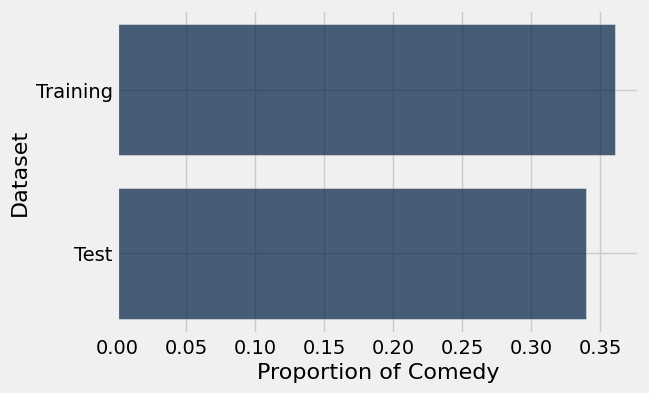

In [5]:
# Step 1 :
#  Create a function to return the proportion of comedy movies in a dataset
# Option 1
def comedy_proportion(table):
    """Return the proportion of movies in a table that have the comedy genre."""
    return table.where('Genre', are.equal_to('comedy')).num_rows / table.num_rows

# Option 2
#def comedy_proportion(table):
#    """Return the proportion of movies in a table that have the comedy genre."""
#    total_movies = table.num_rows
#    comedy_movies = table.where('Genre', are.equal_to('comedy'))
#    return comedy_movies / table.total_movies

# Step 2:
#  Create a table with 2 columns (Dataset and Proportion of Comedy)
# Option 1
datasets = make_array('Training', 'Test')
prop_comedy = make_array(comedy_proportion(train_movies), comedy_proportion(test_movies))
Table().with_columns(
        'Dataset', datasets,
        'Proportion of Comedy', prop_comedy).barh('Dataset')

# Option 2
#train_comedy = comedy_proportion(train_movies)
#test_comedy = comedy_proportion(test_movies)
#comedy_prop_tbl = Table().with_columns(
#                    'Dataset', make_array('Training', 'Test'),
#                    'Proportion of Comedy', make_array(train_comedy, test_comedy)
#                    )
#comedy_prop_tbl.barh('Dataset')

#### Compute the distance between Monty Python and the Holy Grail and The Godfather, using the water and feel features only

In [6]:
python = row_for_title("monty python and the holy grail") 
godfather = row_for_title("the godfather")

# Option 1
one_distance = ((python.item("water") - godfather.item("water"))**2 + (python.item("feel") - godfather.item("feel"))**2)**0.5

# Option 2
#python_water = python.item("water")  # x1
#python_feel = python.item("feel")    # y1
#godfather_water = godfather.item("water")   # x2
#godfather_feel = godfather.item("feel")     # y2
#one_distance = ((python_water - godfather_water)**2 + (python_feel - godfather_feel)**2)**0.5

one_distance

0.0012225209151294461

#### Create a function to computes the distance between any two movies, using two features

In [7]:
# This function will take 2 movie names and 2 features for parameters.
#   It will call row_for_title() function to get the row object of a movie.
#   The row object contains the 5000 features of the movie.
#   row_for_title() will be called twice to get the row objects for the 2 movies.
#   Then the feature values can be retrieved from the row objects
#   for computing the distance of the 2 movies in the context of the 2 features\.
def distance_two_features(title0, title1, x_feature, y_feature):
    """Compute the distance between two movies with titles title0 and title1.
    
    Only the features named x_feature and y_feature are used when computing the distance.
    """
    row0 = row_for_title(title0)
    row1 = row_for_title(title1)
    return ((row0.item(x_feature) - row1.item(x_feature))**2 + (row0.item(y_feature) - row1.item(y_feature))**2)**0.5

#### Create a function to computes the distance between a movie and "monty python and the holy grail", using "water" and "feel" features

In [9]:
# This function will take 1 movie title for parameter.
# It will call distance_two_features() by passing in a movie name, 
#   "monty python and the holy grail", "water" and "feel" as arguments.
# Then, return the distance between a movie and "monty python and the holy grail",
#   in context of "water" and "feel" features.
def distance_from_python(title):
    """The distance between the given movie and "monty python and the holy grail", 
    based on the features "water" and "feel".
    
    This function takes a single argument:
      title: A string, the name of a movie.
    """
    
    return distance_two_features(title, "monty python and the holy grail", "water", "feel")

#### Find the names and genres of the 5 movies in the training set (train_movies table above) closest to "monty python and the holy grail", using "water" and "feel" features

In [10]:
# Option 1
# Step 1:
#  Select 4 columns from the train_movies table - "Title", "Genre", "water", "feel" 
water_feel = train_movies.select("Title", "Genre", "water", "feel")

# Step 2:
#  Use apply method to call distance_from_python() function to 
#  return an array distance between "monty python and the holy grail" and 
#  other movies in the train_movies table
distance_array = water_feel.apply(distance_from_python, 'Title')

# Step 3:
#  Append a new column with distance_array to water_feel table 
water_feel_distance = water_feel.with_column('distance from python', distance_array)

# Step 4:
#  Sort water_feel_distance by column 'distance from python' in ascending order and 
#  take the first 5 rows and name/assign it to close_movies
close_movies = water_feel_distance.sort('distance from python').take(np.arange(5))

# Option 2
#water_feel = train_movies.select("Title", "Genre", "water", "feel")
#close_movies = water_feel.with_column('distance from python', water_feel.apply(distance_from_python, 'Title'))\
#                       .sort('distance from python')\
#                       .take(np.arange(5))

close_movies

Title,Genre,water,feel,distance from python
alien,thriller,0.00070922,0.00124113,0.000193831
tomorrow never dies,thriller,0.000888889,0.000888889,0.00020189
the silence of the lambs,thriller,0.000595948,0.000993246,0.000222563
innerspace,comedy,0.000522193,0.00104439,0.00028324
some like it hot,comedy,0.000528541,0.000951374,0.00030082


#### Predict the genre of "monty python and the holy grail" based on the closest movies

In [11]:
# Create a function to look for the majority of genre in the close_movies table
# Step 1: group the table by class (genre in this case)
# Step 2: sort by count column in descending order
# Step 3: get the first item in the genre column

def most_common(label, table):
    """The most common element in a column of a table.
    
    This function takes two arguments:
      label: The label of a column, a string.
      table: A table.
     
    It returns the most common value in the label column of the table.
    In case of a tie, it returns any one of the most common values.    
    """
    return table.group(label).sort('count', descending=True).column(label).item(0)

In [12]:
most_common('Genre', close_movies)

'thriller'

In [13]:
# Just run this cell to define fast_distances.

def fast_distances(test_row, train_table):
    """Return an array of the distances between test_row and each row in train_table.

    Takes 2 arguments:
      test_row: A row of a table containing features of one
        test movie (e.g., test_my_features.row(0)).
      train_table: A table of features (for example, the whole
        table train_my_features)."""
    assert train_table.num_columns < 50, "Make sure you're not using all the features of the movies table."
    assert type(test_row) != datascience.tables.Table, "Make sure you are passing in a row object to fast_distances."
    assert len(test_row) == len(train_table.row(0)), "Make sure the length of test row is the same as the length of a row in train_table."
    counts_matrix = np.asmatrix(train_table.columns).transpose()
    diff = np.tile(np.array(list(test_row)), [counts_matrix.shape[0], 1]) - counts_matrix
    np.random.seed(0) # For tie breaking purposes
    distances = np.squeeze(np.asarray(np.sqrt(np.square(diff).sum(1))))
    eps = np.random.uniform(size=distances.shape)*1e-10 #Noise for tie break
    distances = distances + eps
    return distances

#### Make an array of at least 10 common words that you think might let you distinguish between comedy and thriller movies and assign the array to my_features

In [ ]:
# this just picks the first 10 words in the feature list and serves as an example. 

my_features = make_array("she",	"decid",	"talk",	"wit",	"razor",	"slam",	"credit",	"rai",	"hugh",	"breez")


train_my_features = train_movies.select(my_features)
test_my_features = test_movies.select(my_features)

#### How to use fast_distances() function

fast_distances() function:
1. takes 2 parameters - a row object from test_my_features and a table - train_my_features table
2. computer the distance of the row object against each row object in the train_my_features table
3. return an array of resulting distances

Row(Title='ghostbusters ii', Year='1989', Rating=6.0999999999999996, Genre='comedy', # Words=6358, she=0.0018133860863831001, decid=0.0, talk=0.0011539729640619, wit=0.00032970656116049999, razor=0.0, slam=0.0, credit=0.0, rai=0.0034619188921858998, hugh=0.0, breez=0.0, conscienc=0.0, audienc=0.00016485328058020001, cathi=0.0, log=0.0, met=0.0, chosen=0.0, grip=0.0, booz=0.0, bianca=0.0, doubl=0.0, agent=0.0, exit=0.0, carpent=0.0, underground=0.0, clemenza=0.0, gain=0.0, neg=0.0, majesti=0.0, studio=0.00032970656116049999, chri=0.0, spin=0.0, greater=0.0, eaten=0.0, vibrat=0.00016485328058020001, stupid=0.00016485328058020001, cigarett=0.0, jesu=0.0, mani=0.00065941312232110005, violin=0.0, financi=0.0, bai=0.0, cop=0.0, neighbor=0.0, cd=0.0, england=0.0, made=0.00065941312232110005, conni=0.0, instinct=0.00016485328058020001, took=0.0008242664029014, jacquelin=0.0, mace=0.0, disappear=0.0, waltz=0.0, behind=0.00049455984174079999, bourbon=0.0, favorit=0.00016485328058020001, benni=0.

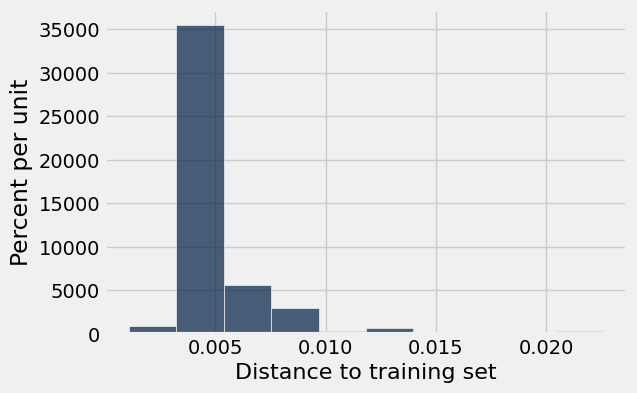

In [29]:
# Example of using fast_distances() function
movie_index = 0
print(test_movies.row(movie_index))
distances = fast_distances(test_my_features.row(movie_index), train_my_features)
Table().with_columns('Distance to training set', distances).hist()


In [28]:
genre_and_distances = Table().with_columns('Title', train_movies.column('Title'), 
                                           'Genre', train_movies.column('Genre'), 
                                           'Distance', distances).sort('Distance')
genre_and_distances.show(5)

Title,Genre,Distance
goodfellas,thriller,0.000900152
the limey,thriller,0.00112042
maniac,thriller,0.00122679
legally blonde,comedy,0.00145204
white angel,thriller,0.00167398
